<a href="https://colab.research.google.com/github/vidhusree/ML-Project/blob/main/vidhusree_kp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/customer_churn.csv')
print(df.head())
df['Churn'].value_counts()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            0.0     Yes         No     1.0           No   
1  5575-GNVDE    Male            0.0      No         No    34.0          Yes   
2  3668-QPYBK    Male            0.0      No         No     2.0          Yes   
3  7795-CFOCW    Male            0.0      No         No    45.0           No   
4  9237-HQITU  Female            0.0      No         No     2.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

,count
Churn,
No,5174
Yes,1869


In [ ]:
print(df.shape)
print(df.describe())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())


(7043, 21)
       SeniorCitizen       tenure  MonthlyCharges
count    7036.000000  7030.000000     7027.000000
mean        0.162024    32.367568       64.757855
std         0.368499    24.560644       30.091845
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7036 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7030 non-null   float64
 6   PhoneService      7030 non-null   object 
 7   Mult

In [ ]:
df_model=df.copy()
print(df_model)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female            0.0     Yes         No     1.0   
1     5575-GNVDE    Male            0.0      No         No    34.0   
2     3668-QPYBK    Male            0.0      No         No     2.0   
3     7795-CFOCW    Male            0.0      No         No    45.0   
4     9237-HQITU  Female            0.0      No         No     2.0   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male            0.0     Yes        Yes    24.0   
7039  2234-XADUH  Female            0.0     Yes        Yes    72.0   
7040  4801-JZAZL  Female            0.0     Yes        Yes    11.0   
7041  8361-LTMKD    Male            1.0     Yes         No     4.0   
7042  3186-AJIEK    Male            0.0      No         No    66.0   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [ ]:
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
print(df_model.info())
print(df_model.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7036 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7030 non-null   float64
 6   PhoneService      7030 non-null   object 
 7   MultipleLines     7030 non-null   object 
 8   InternetService   7006 non-null   object 
 9   OnlineSecurity    7028 non-null   object 
 10  OnlineBackup      7028 non-null   object 
 11  DeviceProtection  7028 non-null   object 
 12  TechSupport       7028 non-null   object 
 13  StreamingTV       7021 non-null   object 
 14  StreamingMovies   7029 non-null   object 
 15  Contract          7018 non-null   object 
 16  PaperlessBilling  7029 non-null   object 


In [ ]:
for col in df_model.select_dtypes(include='object').columns:
    if col not in ['customerID', 'Churn']:
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])


In [ ]:
print(df_model.isnull().sum())
print(df_model.info())


customerID           0
gender               0
SeniorCitizen        7
Partner              0
Dependents           0
tenure              13
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges      16
TotalCharges        18
Churn                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7036 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7030 non-null   float64
 6   PhoneService    

In [ ]:
for col in df_model.select_dtypes(include='number').columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(df_model.isnull().sum())
print(df_model.info())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   obj

In [ ]:
df_model['PhoneService'].value_counts()

,count
PhoneService,
Yes,6362
No,681


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()


cat_cols = [c for c in df_model.select_dtypes('object').columns
            if c not in ['customerID', 'Churn']]
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model['Churn_bin'] = (df_model['Churn'] == 'Yes').astype(int)


In [ ]:
df_model.info()
df_model['gender'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   float64
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


,count
gender,
1,3555
0,3488


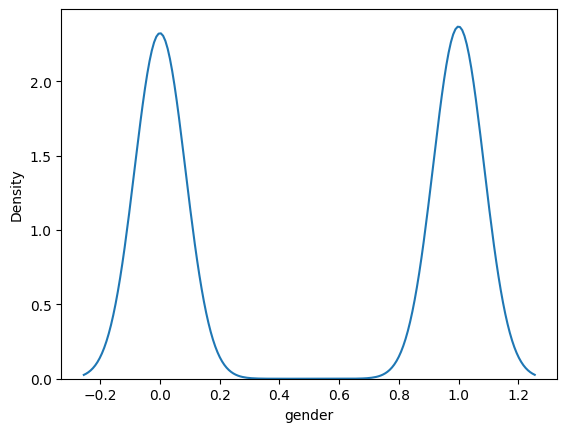

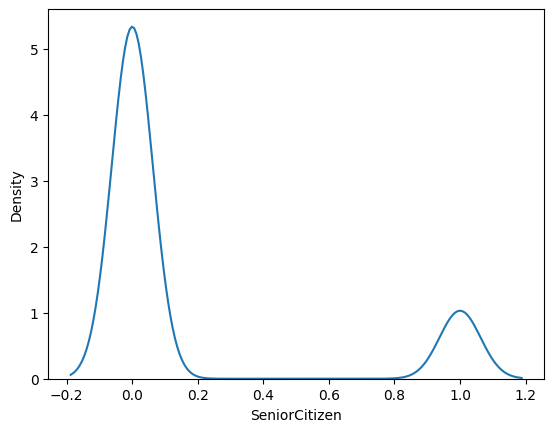

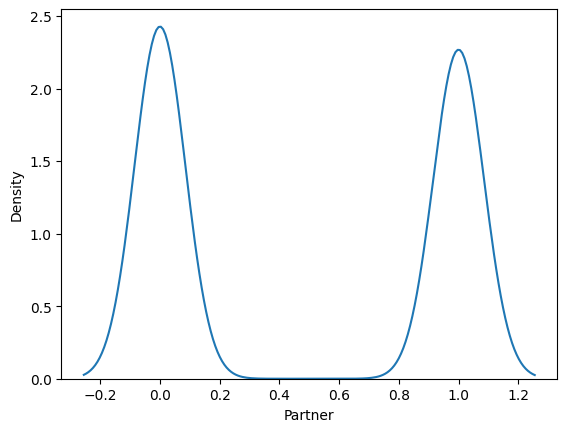

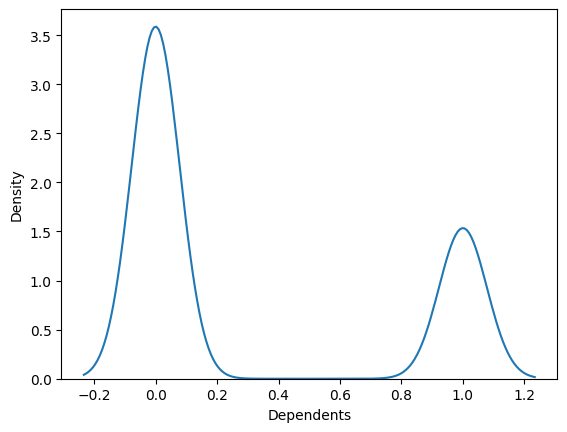

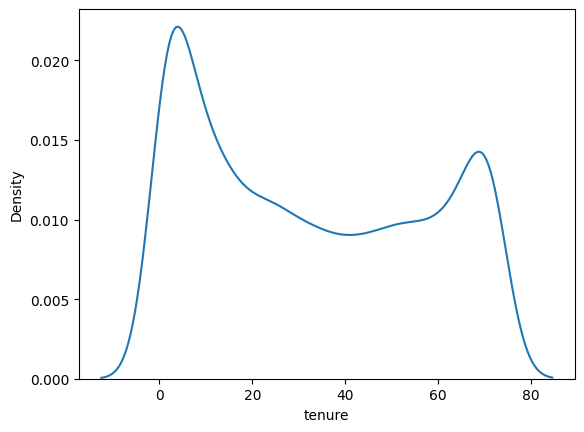

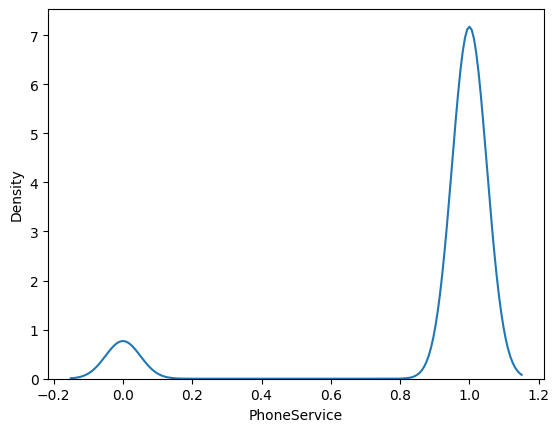

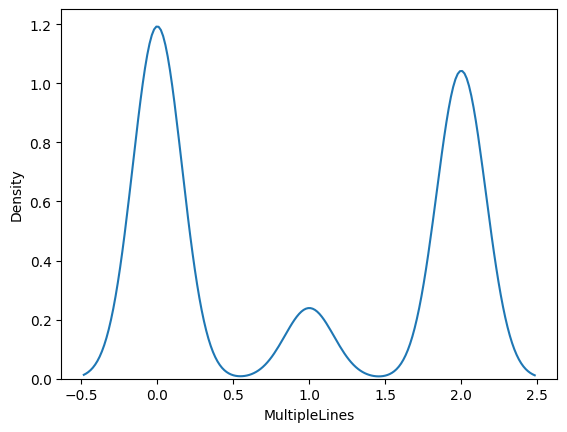

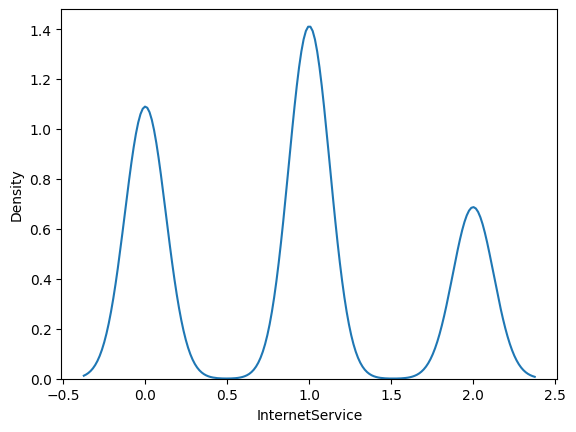

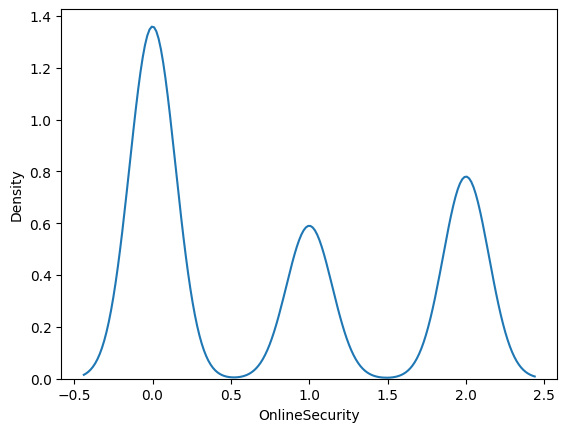

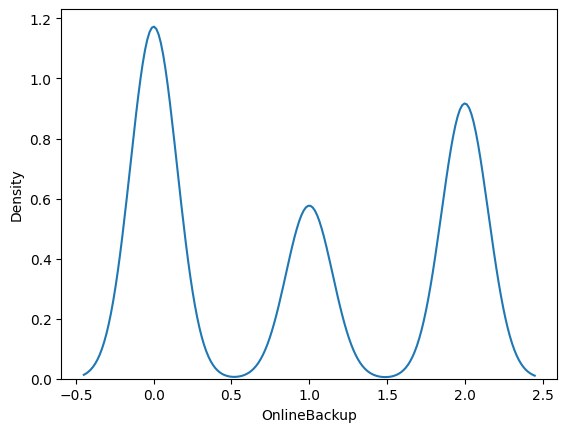

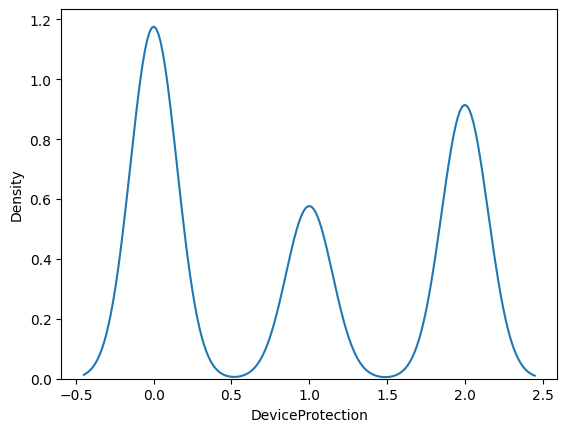

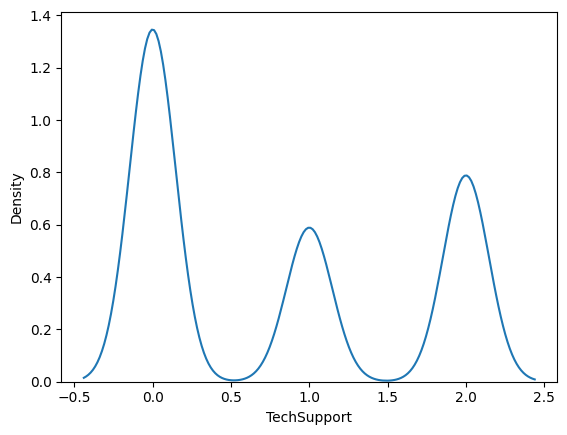

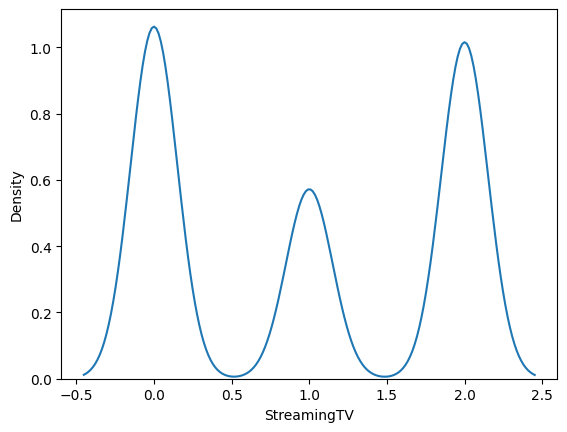

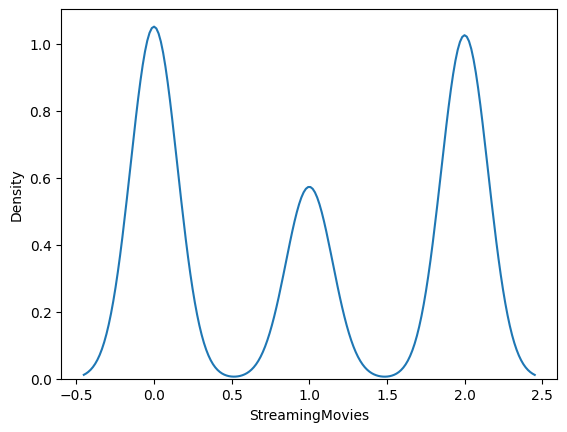

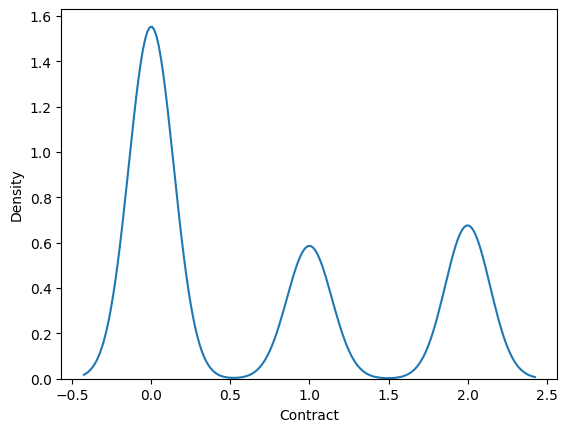

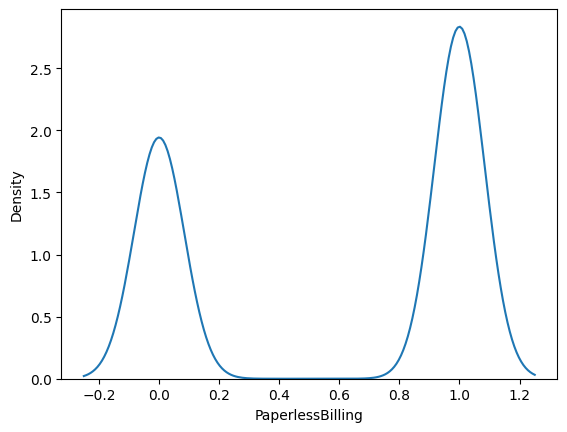

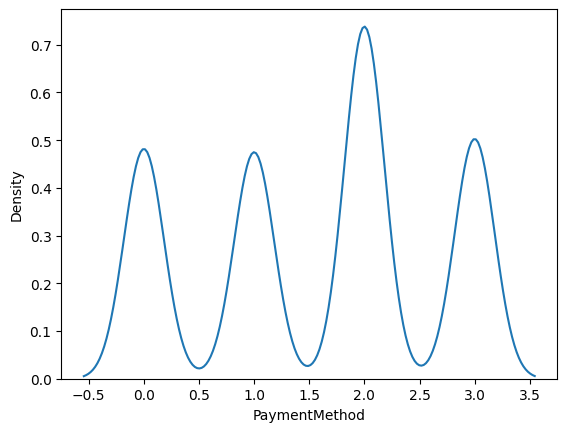

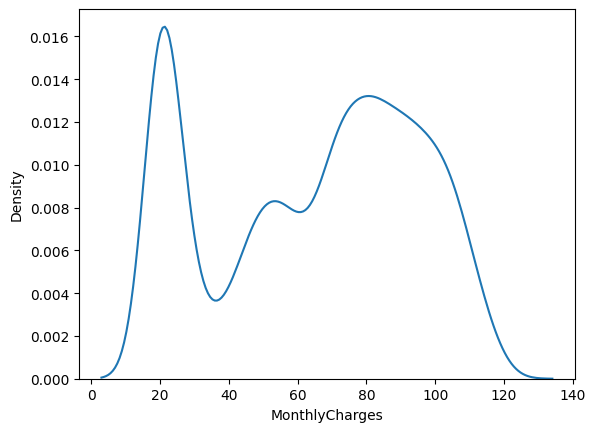

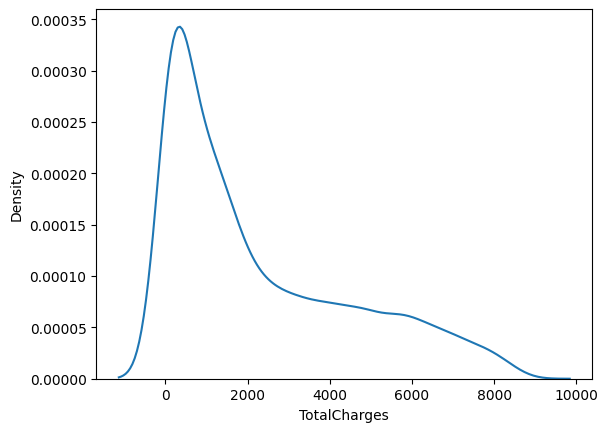

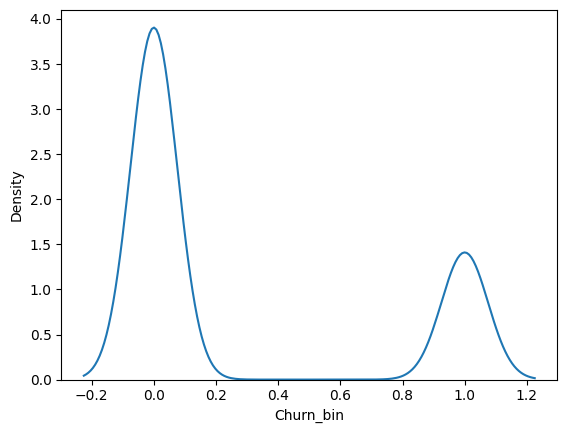

In [ ]:
num_col=pd.DataFrame(df_model.select_dtypes(include='number'))
for col in num_col:
  sns.kdeplot(df_model[col])
  plt.show()

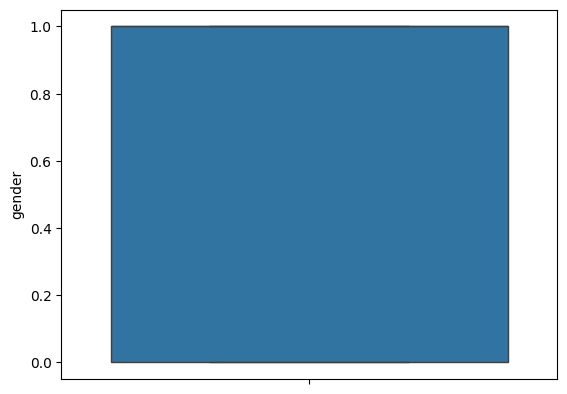

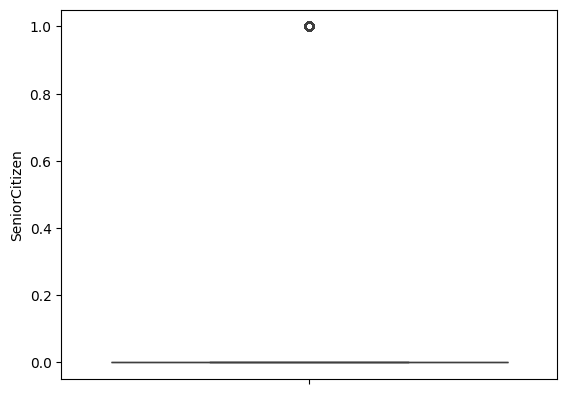

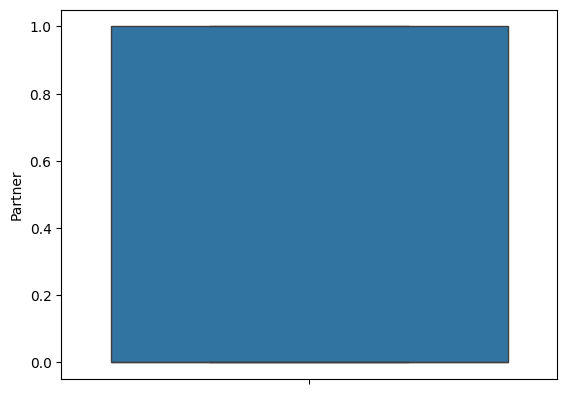

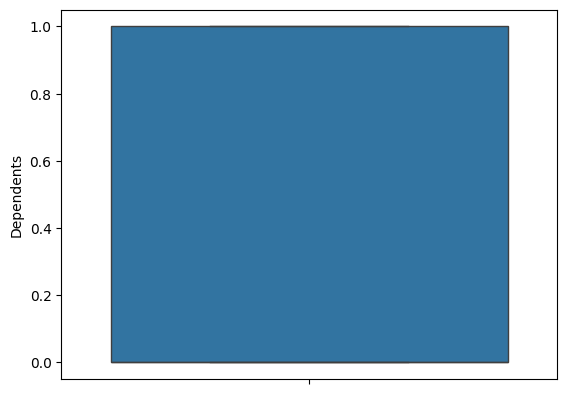

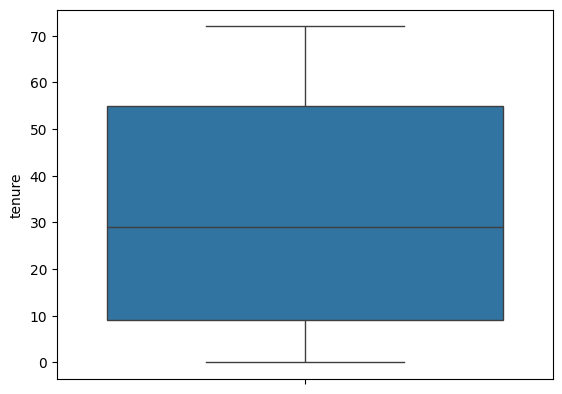

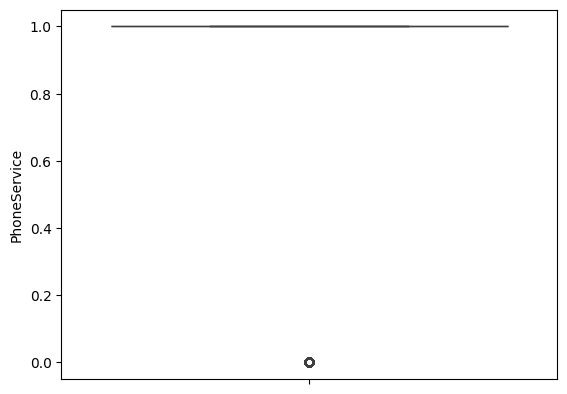

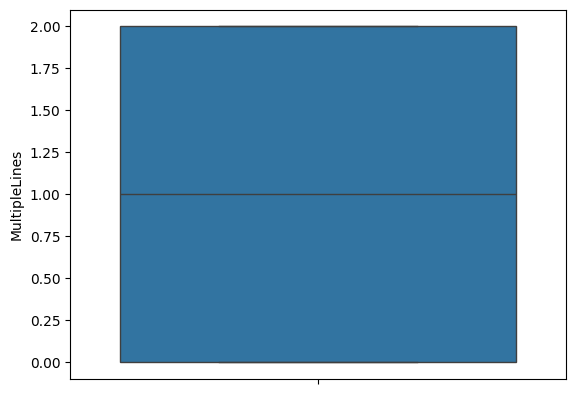

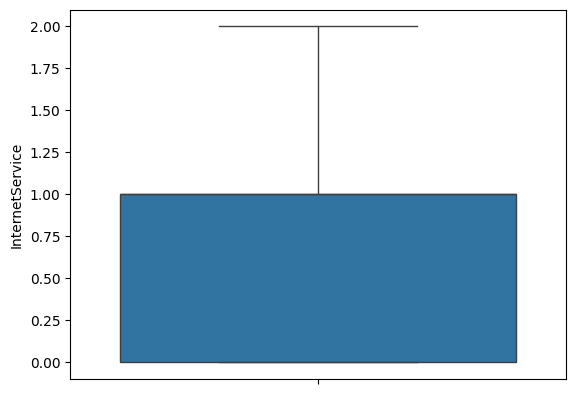

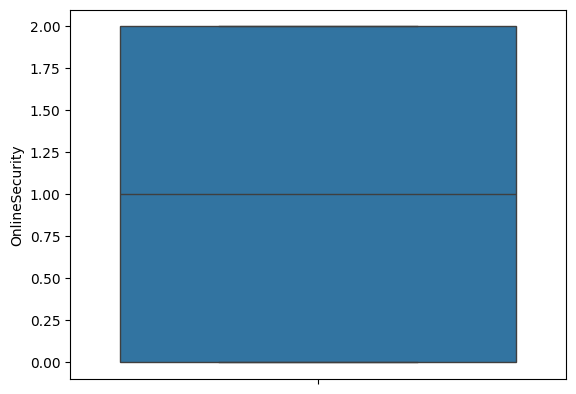

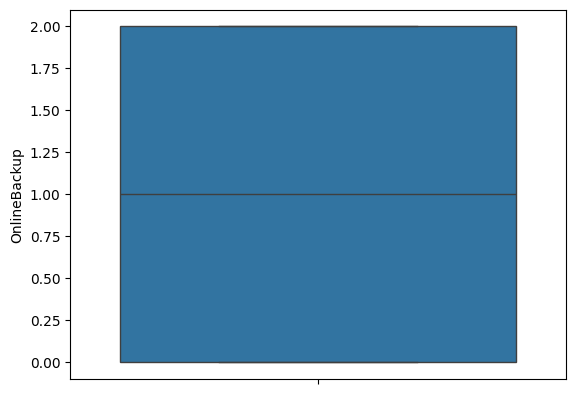

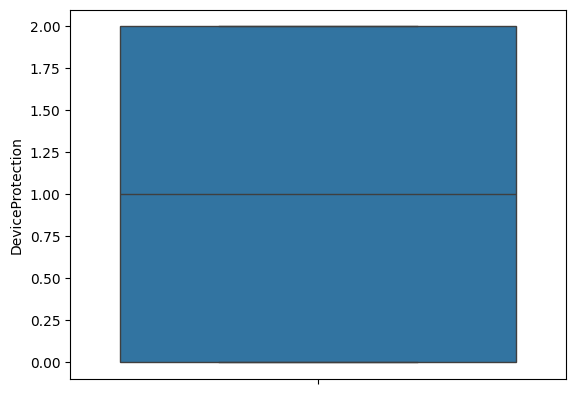

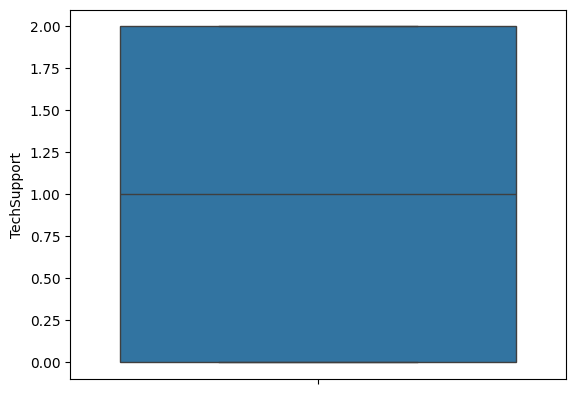

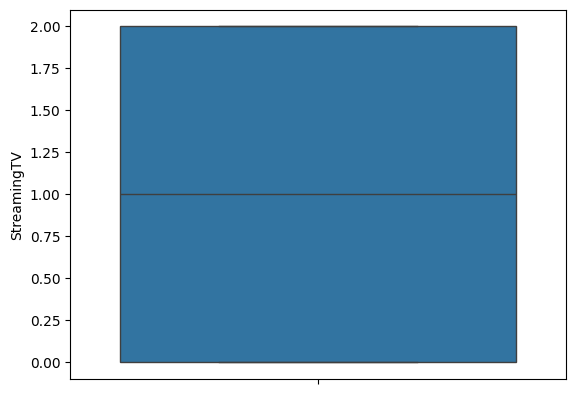

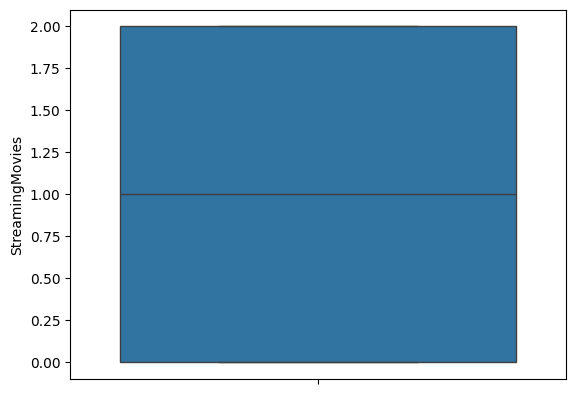

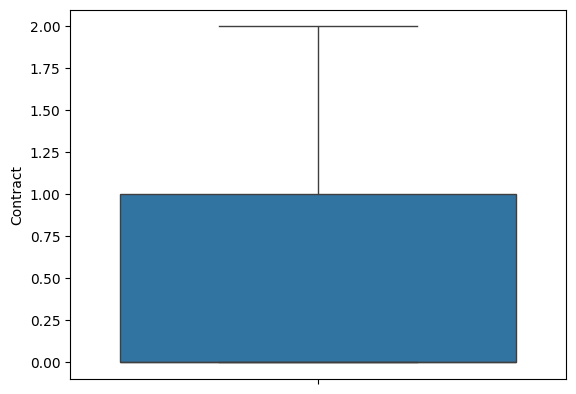

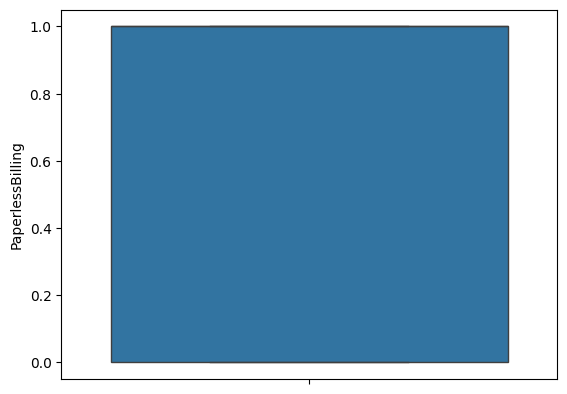

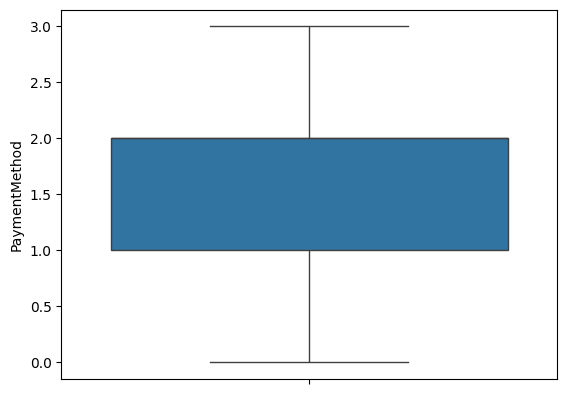

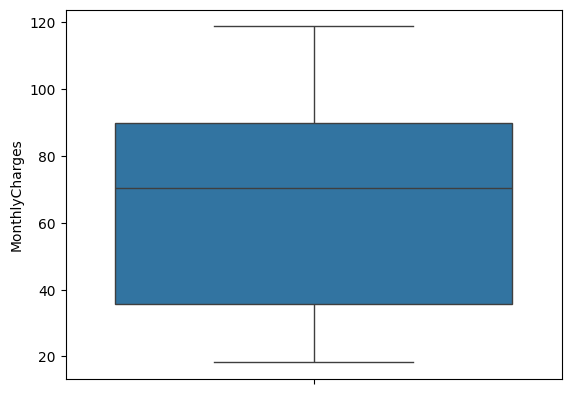

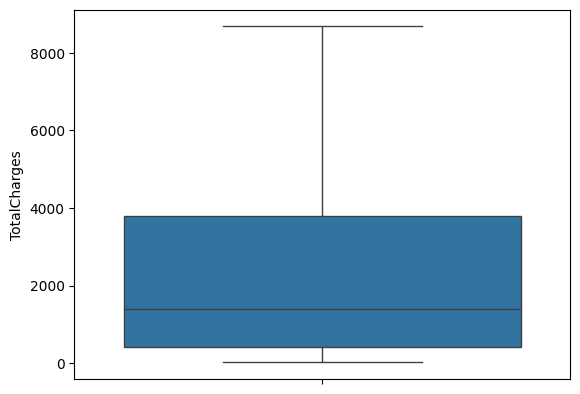

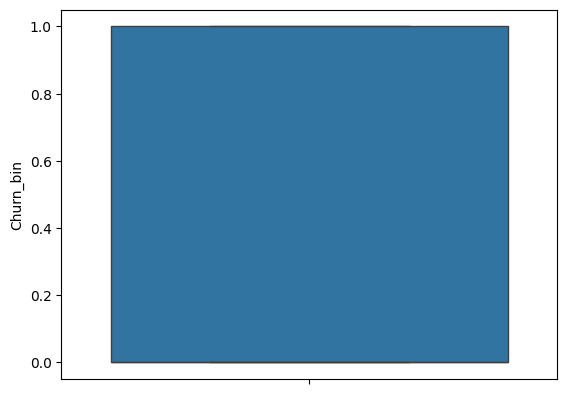

In [ ]:
for col in num_col:
  sns.boxplot(df_model[col])
  plt.show()

In [ ]:
features = [c for c in df_model.columns if c not in ['customerID', 'Churn', 'Churn_bin']]

X = df_model[features]
y = df_model['Churn_bin']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix,classification_report

lr=LogisticRegression()
rf=RandomForestClassifier()
gb=GradientBoostingClassifier()

In [ ]:
lr=LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test_sc)
y_prob = lr.predict_proba(X_test_sc)[:, 1]


accuracy=accuracy_score(y_test, y_pred)
Confusion_Matrix=confusion_matrix(y_test, y_pred)
Classification_Report=classification_report(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:",Confusion_Matrix)
print("precision:",precision)
print("recall:",recall)

print("=" * 50)
print("LOGISTIC REGRESSION — RESULTS")
print("=" * 50)
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))


Accuracy: 0.8147622427253371
Confusion Matrix: [[932 104]
 [157 216]]
precision: 0.675
recall: 0.579088471849866
LOGISTIC REGRESSION — RESULTS
AUC-ROC  : 0.8589

Classification Report:
              precision    recall  f1-score   support

        Stay       0.86      0.90      0.88      1036
       Churn       0.68      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

accuracy=accuracy_score(y_test, y_pred)
Confusion_Matrix=confusion_matrix(y_test, y_pred)
Classification_Report=classification_report(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:",Confusion_Matrix)
print("precision:",precision)
print("recall:",recall)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST — RESULTS")
print("=" * 50)
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))


Accuracy: 0.7970191625266146
Confusion Matrix: [[945  91]
 [195 178]]
precision: 0.6617100371747212
recall: 0.4772117962466488
RANDOM FOREST — RESULTS
AUC-ROC  : 0.8335

Classification Report:
              precision    recall  f1-score   support

        Stay       0.83      0.91      0.87      1036
       Churn       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



In [ ]:
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)

y_pred = gbm.predict(X_test)
y_prob = gbm.predict_proba(X_test)[:, 1]

accuracy=accuracy_score(y_test, y_pred)
Confusion_Matrix=confusion_matrix(y_test, y_pred)
Classification_Report=classification_report(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:",Confusion_Matrix)
print("precision:",precision)
print("recall:",recall)


print("=" * 50)
print("GRADIENT BOOSTING — RESULTS")
print("=" * 50)
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))


Accuracy: 0.8090844570617459
Confusion Matrix: [[938  98]
 [171 202]]
precision: 0.6733333333333333
recall: 0.5415549597855228
GRADIENT BOOSTING — RESULTS
AUC-ROC  : 0.8582

Classification Report:
              precision    recall  f1-score   support

        Stay       0.85      0.91      0.87      1036
       Churn       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



The telecom company has a 26.5% churn rate, meaning roughly 1 in 4 customers is leaving. Three models were built to predict who churns next — Logistic Regression, Random Forest, and Gradient Boosting — with Gradient Boosting performing best (AUC ~0.845).
The core finding is straightforward: customers are most likely to leave when they are on month-to-month contracts, have been with the company less than a year, pay high monthly charges, and lack add-on services like online security. These customers feel little loyalty and low perceived value.
The business solution is equally direct — convert at-risk customers to longer contracts, improve early onboarding in the first 12 months, and offer security bundles to high-bill fiber optic users. Retaining even a fraction of these customers would significantly recover lost revenue.
